# Day 3: Exploratory Data Analysis (EDA)
## Bluestock Fintech — Mutual Fund Analytics Platform

In [1]:
import sys
import logging
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sys.path.insert(0, str(Path.cwd().parent / "src"))
import config

# Logger
log_file = config.REPORTS_DIR / "etl_pipeline.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(log_file, mode="a", encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ]
)
logger = logging.getLogger("EDA")
logger.info("=" * 60)
logger.info("DAY 3 — EDA Analysis Started")

# Style
sns.set_theme(style="whitegrid")
CHARTS_DIR = config.REPORTS_DIR

2026-06-27 22:44:51,484 [INFO] ============================================================


2026-06-27 22:44:51,491 [INFO] DAY 3 — EDA Analysis Started


In [2]:
# Load clean_nav.csv
df_nav = pd.read_csv(config.DATA_PROCESSED_DIR / "clean_nav.csv")
df_nav['date'] = pd.to_datetime(df_nav['date'])
logger.info(f"Loaded clean_nav.csv: {df_nav.shape}")

# Load RAW datasets
raw_files = {
    "01_fund_master.csv": "df_funds",
    "03_aum_by_fund_house.csv": "df_aum",
    "04_monthly_sip_inflows.csv": "df_sip_inflows",
    "05_category_inflows.csv": "df_cat_inflows",
    "06_industry_folio_count.csv": "df_folios",
    "08_investor_transactions.csv": "df_tx",
    "09_portfolio_holdings.csv": "df_holdings",
    "10_benchmark_indices.csv": "df_benchmarks"
}
dfs = {}
for f, var_name in raw_files.items():
    df = pd.read_csv(config.DATA_RAW_DIR / f)
    # Parse relevant dates
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)
    if 'month' in df.columns:
        df['month'] = pd.to_datetime(df['month'], format='mixed', dayfirst=True)
    if 'transaction_date' in df.columns:
        df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', dayfirst=True)
    dfs[var_name] = df
    logger.info(f"Loaded {f}: {df.shape}")

df_funds = dfs['df_funds']
df_aum = dfs['df_aum']
df_sip_inflows = dfs['df_sip_inflows']
df_cat_inflows = dfs['df_cat_inflows']
df_folios = dfs['df_folios']
df_tx = dfs['df_tx']
df_holdings = dfs['df_holdings']
df_benchmarks = dfs['df_benchmarks']

2026-06-27 22:44:51,677 [INFO] Loaded clean_nav.csv: (51400, 3)


2026-06-27 22:44:51,687 [INFO] Loaded 01_fund_master.csv: (40, 15)


2026-06-27 22:44:51,712 [INFO] Loaded 03_aum_by_fund_house.csv: (90, 5)


2026-06-27 22:44:51,718 [INFO] Loaded 04_monthly_sip_inflows.csv: (48, 6)


2026-06-27 22:44:51,724 [INFO] Loaded 05_category_inflows.csv: (144, 3)


2026-06-27 22:44:51,732 [INFO] Loaded 06_industry_folio_count.csv: (21, 6)


2026-06-27 22:44:51,886 [INFO] Loaded 08_investor_transactions.csv: (32778, 13)


2026-06-27 22:44:51,892 [INFO] Loaded 09_portfolio_holdings.csv: (322, 8)


2026-06-27 22:44:52,400 [INFO] Loaded 10_benchmark_indices.csv: (8050, 3)


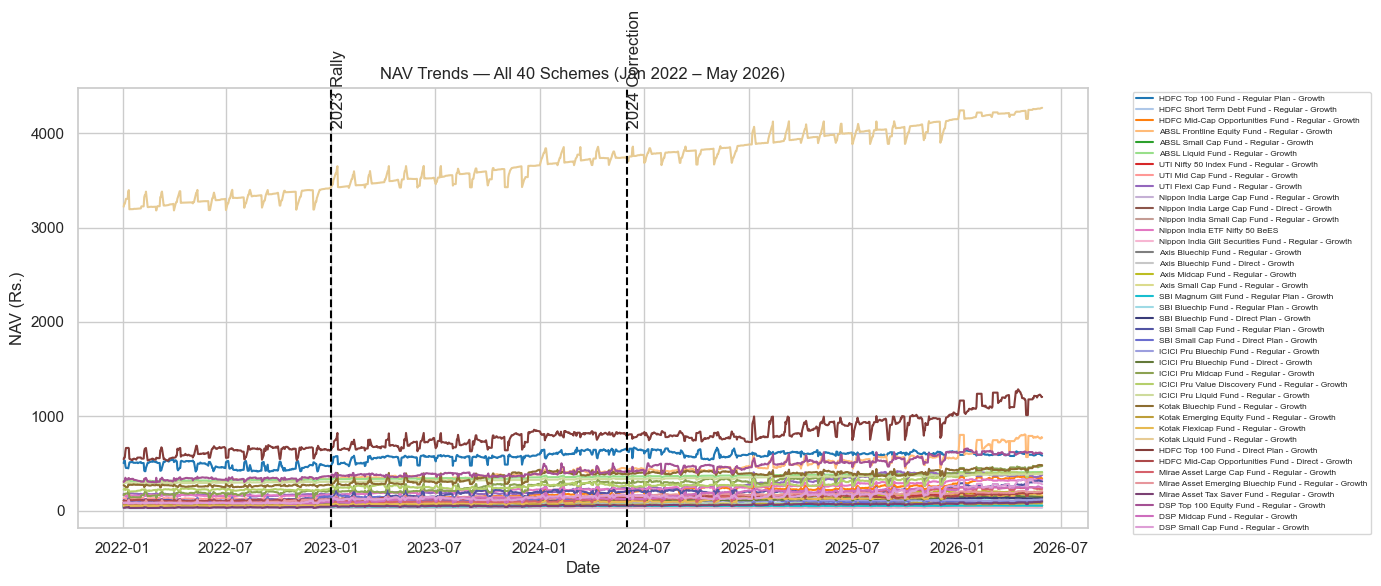

In [3]:
# Chart 1: NAV Trends
df1 = df_nav[(df_nav['date'] >= '2022-01-03') & (df_nav['date'] <= '2026-05-29')].copy()
df1 = df1.merge(df_funds[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

plt.figure(figsize=(14, 6))
# Using a large colormap list by combining tab20 and tab20b
colors = plt.cm.tab20.colors + plt.cm.tab20b.colors

for i, (code, group) in enumerate(df1.groupby('amfi_code')):
    scheme_name = group['scheme_name'].iloc[0] if not group['scheme_name'].empty else str(code)
    plt.plot(group['date'], group['nav'], label=scheme_name, color=colors[i % len(colors)])

plt.title("NAV Trends — All 40 Schemes (Jan 2022 – May 2026)")
plt.xlabel("Date")
plt.ylabel("NAV (Rs.)")

plt.axvline(pd.to_datetime('2023-01-01'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-01-01'), plt.ylim()[1]*0.9, ' 2023 Rally', rotation=90)
plt.axvline(pd.to_datetime('2024-06-01'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-06-01'), plt.ylim()[1]*0.9, ' 2024 Correction', rotation=90)

plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=6)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart_01_nav_trends.png")
plt.show()

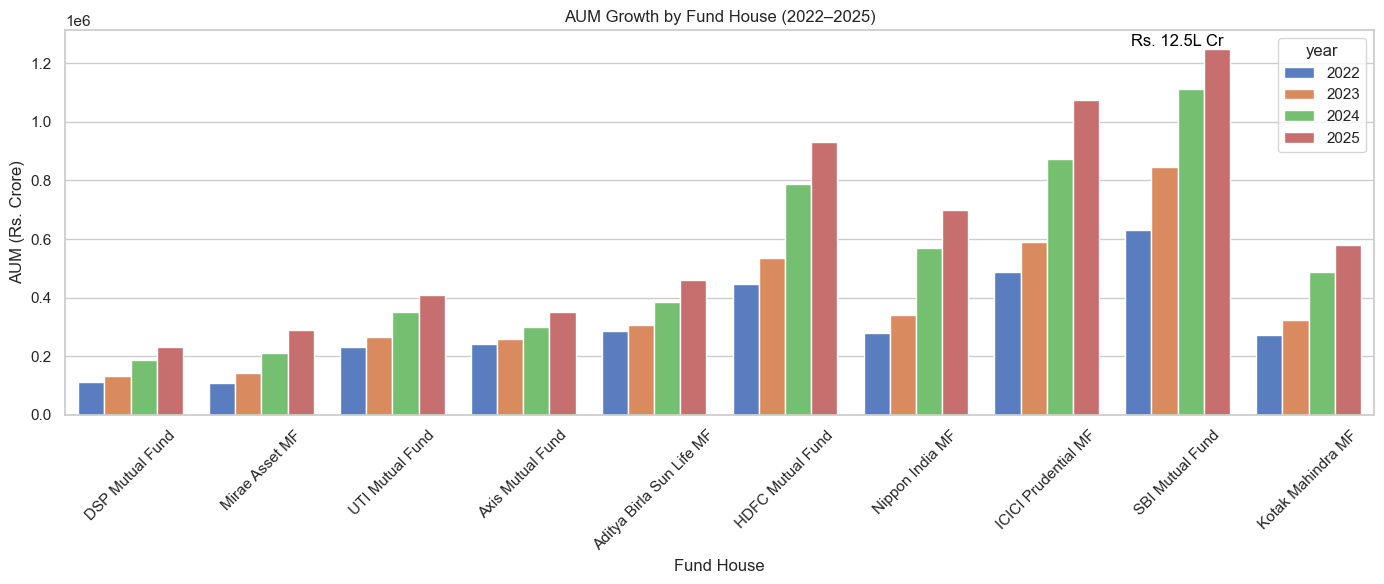

In [4]:
# Chart 2: AUM Growth Grouped Bar Chart
df2 = df_aum.copy()
df2['year'] = df2['date'].dt.year
# Group by year and fund house, take the last AUM value
df2_last = df2.sort_values('date').groupby(['year', 'fund_house']).tail(1)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df2_last, x='fund_house', y='aum_crore', hue='year', palette='muted')
plt.xticks(rotation=45)
plt.title("AUM Growth by Fund House (2022–2025)")
plt.ylabel("AUM (Rs. Crore)")
plt.xlabel("Fund House")

# Annotate SBI Mutual Fund's 2025 bar
for p in ax.patches:
    # Need to find the correct bar (SBI 2025). We can also just place text manually if it's simpler, but let's place manually.
    pass

# Alternatively, manual placement:
# We know SBI is one of the fund houses on the X axis.
sbi_idx = list(df2_last['fund_house'].unique()).index('SBI Mutual Fund') if 'SBI Mutual Fund' in df2_last['fund_house'].unique() else 0
plt.text(sbi_idx, 1250000, "Rs. 12.5L Cr", ha='center', va='bottom', color='black') # Approx positioning based on 12.5L crore

plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart_02_aum_growth.png")
plt.show()

In [5]:
# Chart 3: SIP Inflow Time-Series
df3 = df_sip_inflows.copy()
df3 = df3.sort_values('month')
df3_month_str = df3['month'].dt.strftime('%Y-%m-%d')

fig = go.Figure()
fig.add_trace(go.Scatter(x=df3_month_str, y=df3['sip_inflow_crore'], mode='lines+markers', name='SIP Inflow'))

fig.add_vline(x='2025-12-01', line_dash="dash", line_color="black")
fig.add_annotation(x='2025-12-01', y=31002, text="Rs. 31,002 Cr (All-Time High)", showarrow=True, arrowhead=1)

fig.update_layout(
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Rs. Crore)",
    width=1000, height=500
)

fig.write_image(str(CHARTS_DIR / "chart_03_sip_inflow.png"))
fig.show()

2026-06-27 22:44:57,541 [INFO] Chromium init'ed with kwargs {}


2026-06-27 22:44:57,566 [INFO] Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


2026-06-27 22:44:57,570 [INFO] Temp directory created: C:\Users\Dell\AppData\Local\Temp\tmphejsdkfe.


2026-06-27 22:44:57,575 [INFO] Opening browser.


2026-06-27 22:44:57,580 [INFO] Temp directory created: C:\Users\Dell\AppData\Local\Temp\tmp3g62axpm.


...

2026-06-27 22:45:06,021 [INFO] shutil.rmtree worked.


2026-06-27 22:45:06,022 [INFO] Cancelling tasks.


2026-06-27 22:45:06,024 [INFO] Exiting Kaleido/Choreo.


2026-06-27 22:45:06,041 [INFO] TemporaryDirectory.cleanup() worked.


2026-06-27 22:45:06,042 [INFO] shutil.rmtree worked.


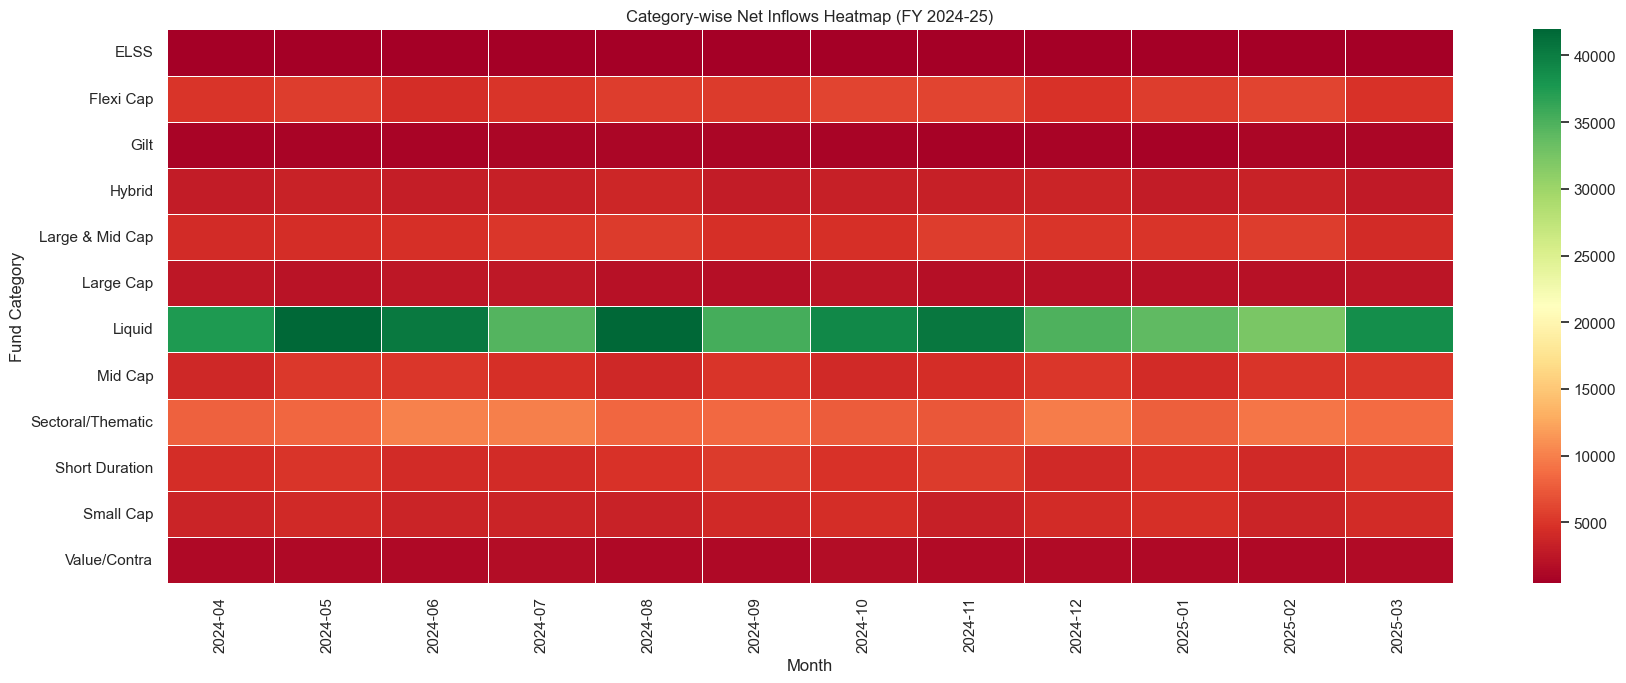

In [6]:
# Chart 4: Category-wise Inflow Heatmap
df4 = df_cat_inflows.copy()
df4_pivot = df4.pivot_table(index='category', columns='month', values='net_inflow_crore', aggfunc='sum')
# Format columns to string for better display on X axis
df4_pivot.columns = df4_pivot.columns.strftime('%Y-%m')

plt.figure(figsize=(18, 7))
sns.heatmap(df4_pivot, cmap="RdYlGn", annot=False, fmt=".0f", linewidths=0.5)
plt.xticks(rotation=90)
plt.title("Category-wise Net Inflows Heatmap (FY 2024-25)")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart_04_category_heatmap.png")
plt.show()

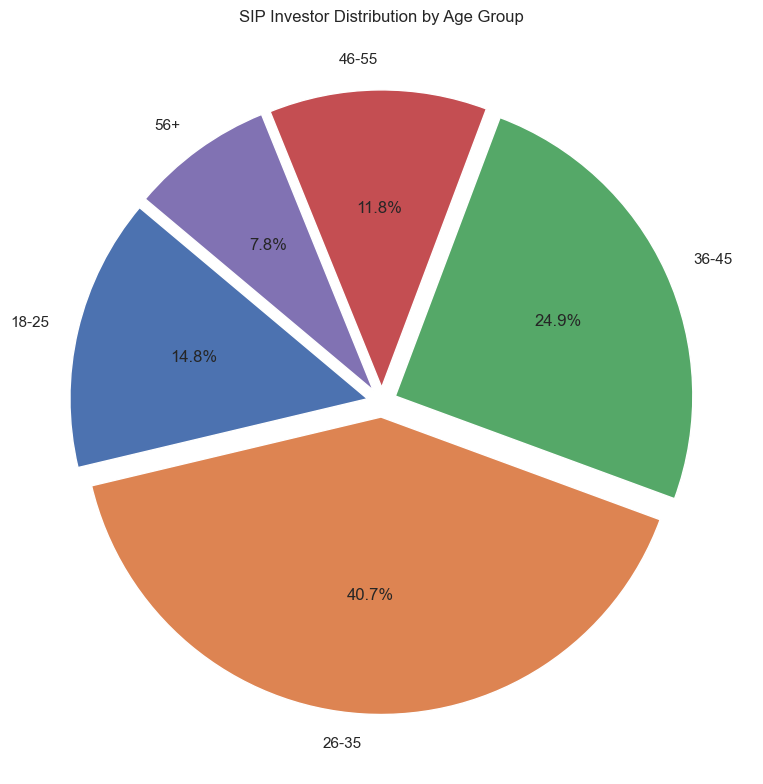

In [7]:
# Chart 5: SIP Investor Distribution by Age Group
df5 = df_tx[df_tx['transaction_type'].str.upper() == 'SIP'].copy()
age_counts = df5.groupby('age_group')['investor_id'].nunique().reindex(['18-25', '26-35', '36-45', '46-55', '56+'])

plt.figure(figsize=(8, 8))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, explode=(0.05,)*5)
plt.title("SIP Investor Distribution by Age Group")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart_05_age_distribution.png")
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_22148\2021387188.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df5, x='age_group', y='amount_inr', order=['18-25','26-35','36-45','46-55','56+'], palette="Set2")


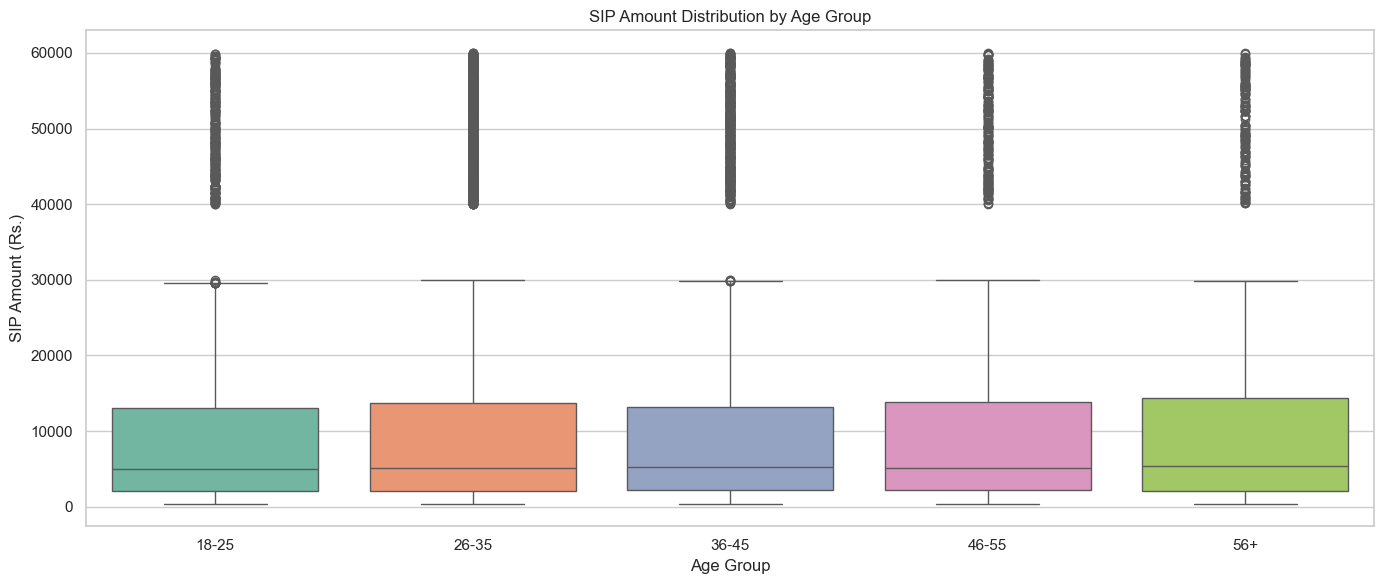

In [8]:
# Chart 6: SIP Amount Boxplot by Age Group
plt.figure(figsize=(14, 6))
sns.boxplot(data=df5, x='age_group', y='amount_inr', order=['18-25','26-35','36-45','46-55','56+'], palette="Set2")
plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (Rs.)")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart_06_sip_boxplot.png")
plt.show()

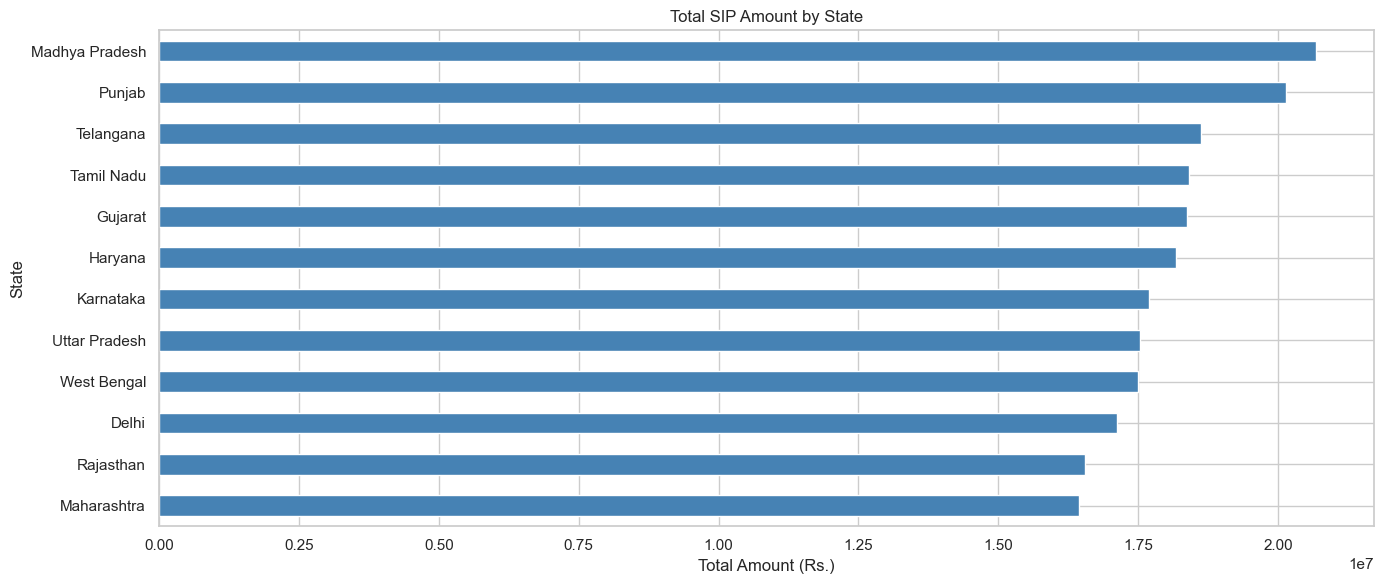

In [9]:
# Chart 7: Total SIP Amount by State
state_amt = df5.groupby('state')['amount_inr'].sum().sort_values(ascending=True) # Ascending for barh

plt.figure(figsize=(14, 6))
state_amt.plot(kind='barh', color='steelblue')
plt.title("Total SIP Amount by State")
plt.xlabel("Total Amount (Rs.)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart_07_geo_state.png")
plt.show()

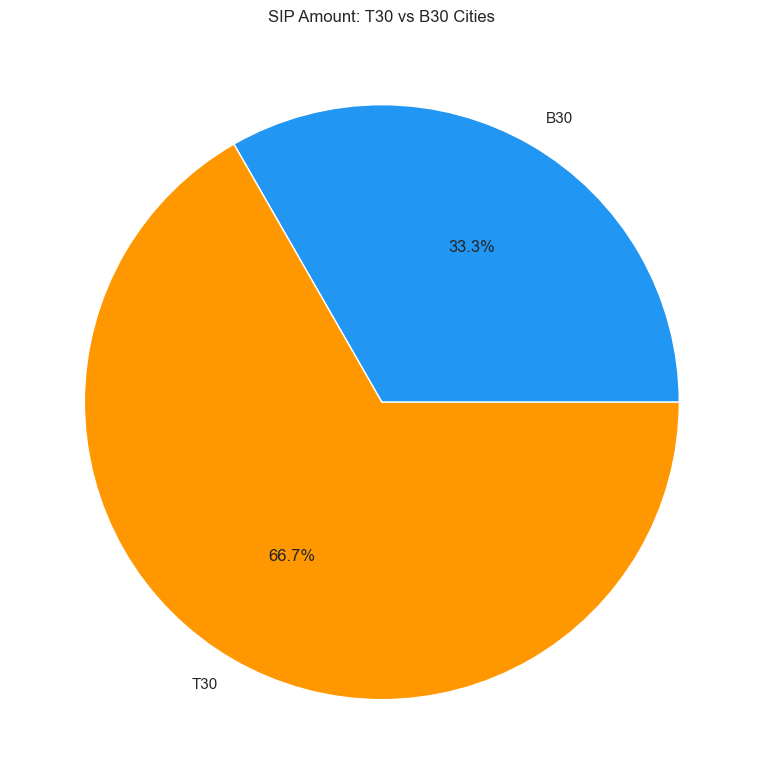

In [10]:
# Chart 8: T30 vs B30 Pie Chart
tier_amt = df5.groupby('city_tier')['amount_inr'].sum()

plt.figure(figsize=(8, 8))
plt.pie(tier_amt, labels=tier_amt.index, autopct='%1.1f%%', colors=['#2196F3','#FF9800'])
plt.title("SIP Amount: T30 vs B30 Cities")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart_08_t30_b30.png")
plt.show()

In [11]:
# Chart 9: Folio Count Growth
df9 = df_folios.sort_values('month')
df9_month_str = df9['month'].dt.strftime('%Y-%m-%d')

fig = go.Figure()
fig.add_trace(go.Scatter(x=df9_month_str, y=df9['total_folios_crore'], mode='lines+markers', name='Total Folios', line_color="#1565C0"))
fig.add_trace(go.Scatter(x=df9_month_str, y=df9['equity_folios_crore'], mode='lines+markers', name='Equity Folios', line_color="#43A047"))

# Annotations
first_month = df9_month_str.iloc[0]
last_month = df9_month_str.iloc[-1]
fig.add_annotation(x=first_month, y=13.26, text="13.26 Cr", showarrow=True)
fig.add_annotation(x=last_month, y=26.12, text="26.12 Cr", showarrow=True)

fig.update_layout(
    title="Industry Folio Count Growth (Jan 2022 – Dec 2025)",
    yaxis_title="Folios (Crore)",
    xaxis_title="Month",
    width=1000, height=500
)

fig.write_image(str(CHARTS_DIR / "chart_09_folio_growth.png"))
fig.show()

2026-06-27 22:45:09,081 [INFO] Chromium init'ed with kwargs {}


2026-06-27 22:45:09,087 [INFO] Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


2026-06-27 22:45:09,089 [INFO] Temp directory created: C:\Users\Dell\AppData\Local\Temp\tmpesvfh80y.


2026-06-27 22:45:09,094 [INFO] Opening browser.


2026-06-27 22:45:09,098 [INFO] Temp directory created: C:\Users\Dell\AppData\Local\Temp\tmp8aq17ws2.


...

2026-06-27 22:45:16,391 [INFO] Exiting Kaleido/Choreo.


2026-06-27 22:45:17,082 [INFO] TemporaryDirectory.cleanup() worked.


2026-06-27 22:45:17,084 [INFO] shutil.rmtree worked.


2026-06-27 22:45:17,086 [INFO] Cancelling tasks.


2026-06-27 22:45:17,087 [INFO] Exiting Kaleido/Choreo.


2026-06-27 22:45:17,160 [INFO] TemporaryDirectory.cleanup() worked.


2026-06-27 22:45:17,163 [INFO] shutil.rmtree worked.


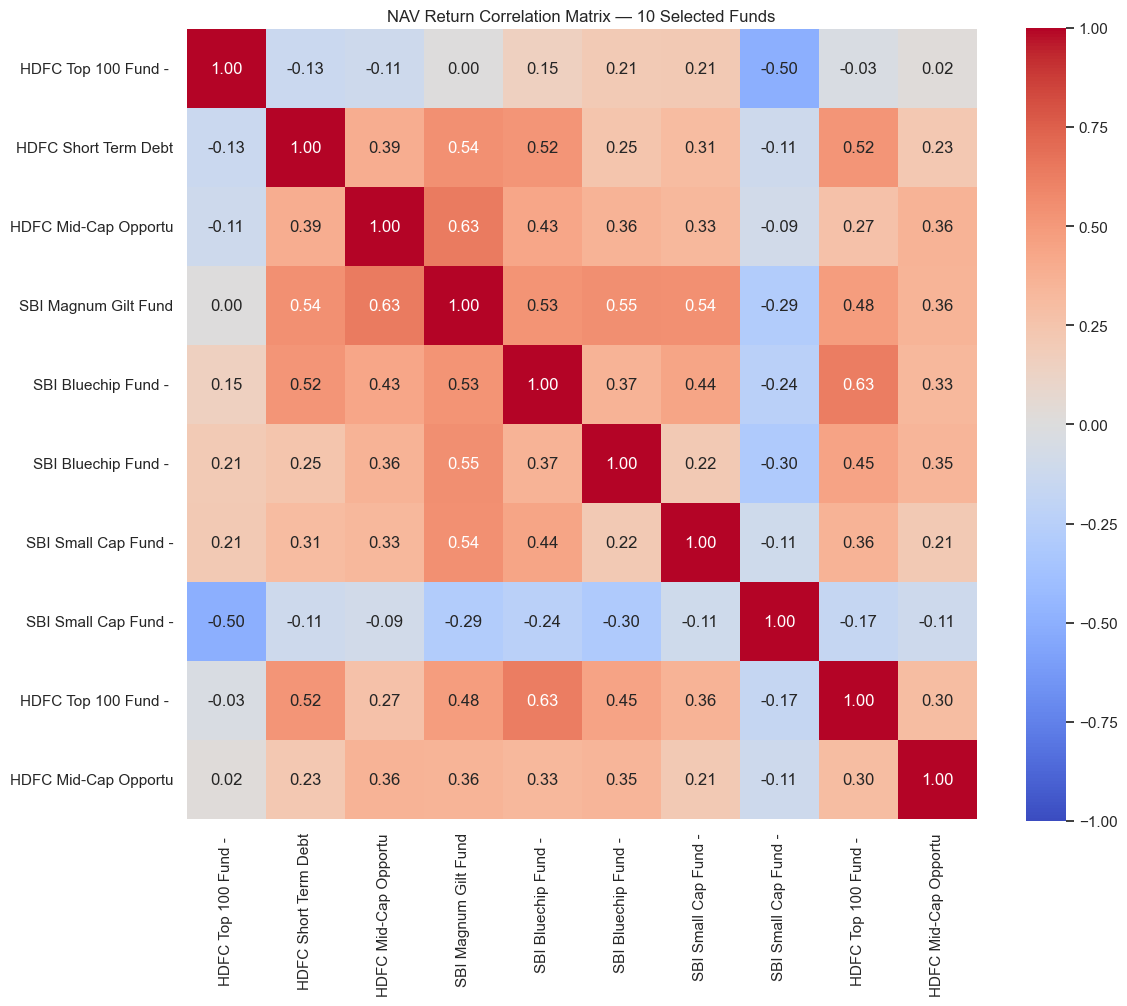

In [12]:
# Chart 10: NAV Return Correlation Matrix
selected_funds = [119551, 119552, 119598, 119599, 100016, 125497, 100033, 125498, 100025, 119120]
df10 = df_nav[df_nav['amfi_code'].isin(selected_funds)].copy()
df10 = df10.sort_values(['amfi_code', 'date'])
df10['daily_return'] = df10.groupby('amfi_code')['nav'].pct_change()

df10_pivot = df10.pivot(index='date', columns='amfi_code', values='daily_return')

# Join with fund master for names
fund_map = dict(zip(df_funds['amfi_code'], df_funds['scheme_name'].str[:20]))
df10_pivot.columns = [fund_map.get(c, str(c)) for c in df10_pivot.columns]

corr_matrix = df10_pivot.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("NAV Return Correlation Matrix — 10 Selected Funds")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart_10_correlation_matrix.png")
plt.show()

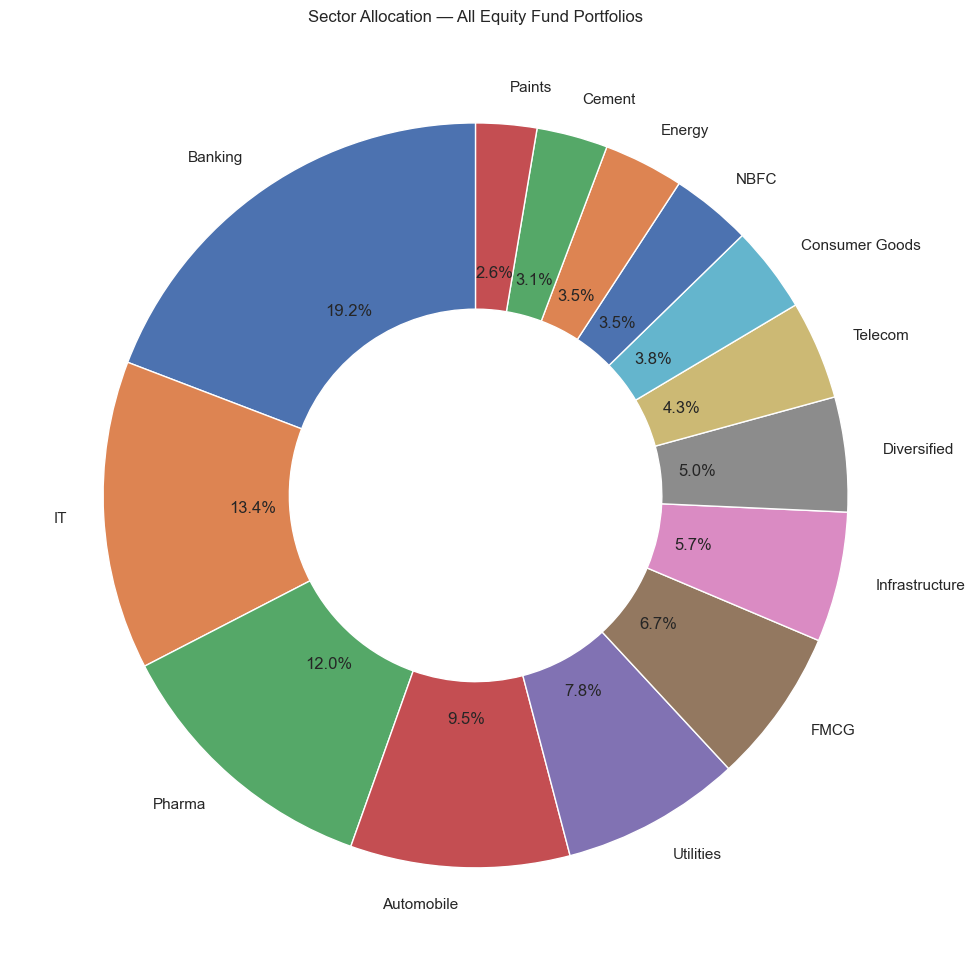

In [13]:
# Chart 11: Sector Allocation Donut
df11 = df_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 10))
plt.pie(df11, labels=df11.index, wedgeprops=dict(width=0.5), autopct='%1.1f%%', startangle=90)
plt.title("Sector Allocation — All Equity Fund Portfolios")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart_11_sector_donut.png")
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_22148\546221167.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df12, x='sector', y='weight_pct', palette='viridis')


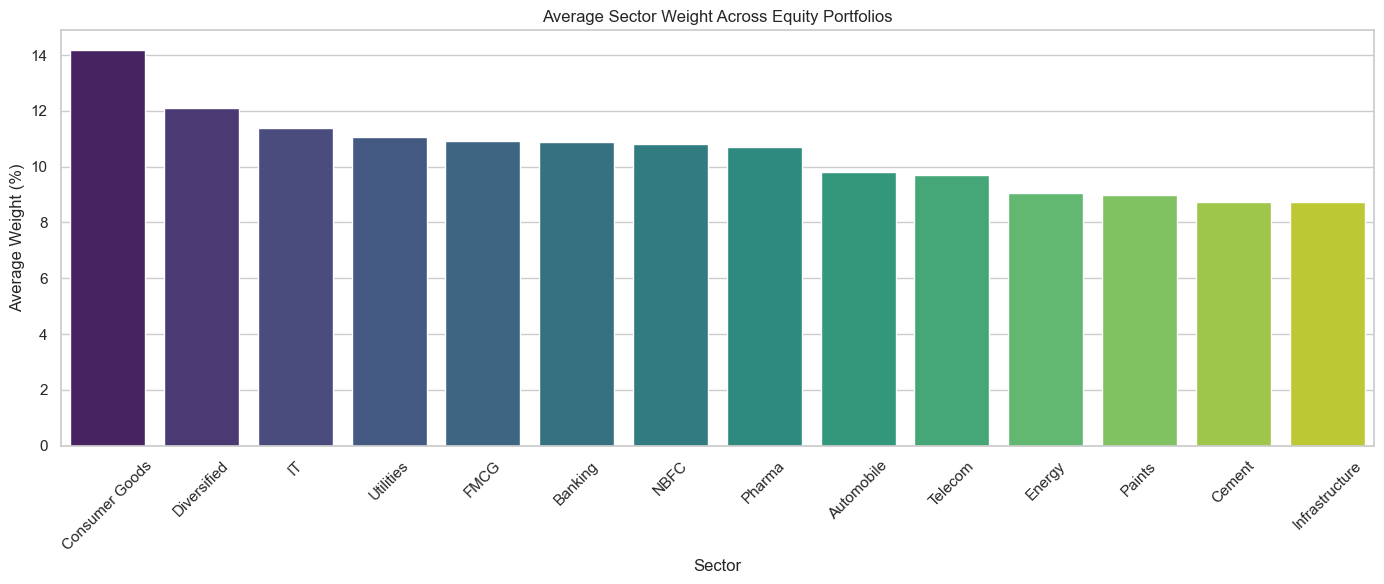

In [14]:
# Chart 12: Average Sector Weight Bar
df12 = df_holdings.groupby('sector')['weight_pct'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=df12, x='sector', y='weight_pct', palette='viridis')
plt.xticks(rotation=45)
plt.title("Average Sector Weight Across Equity Portfolios")
plt.ylabel("Average Weight (%)")
plt.xlabel("Sector")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart_12_sector_bar.png")
plt.show()

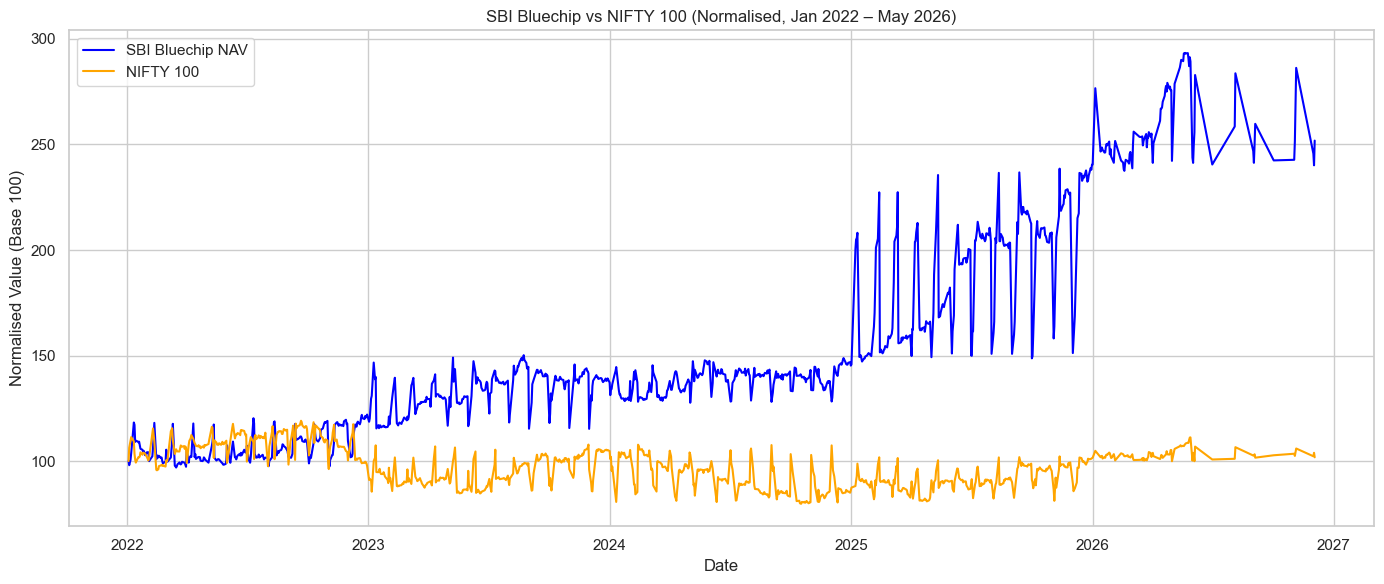

In [15]:
# Chart 13: SBI Bluechip vs NIFTY 100 (Normalised)
sbi_nav = df_nav[df_nav['amfi_code'] == 119551].copy()
bench_100 = df_benchmarks[df_benchmarks['index_name'] == 'NIFTY100'].copy()

# Filter common date range roughly
merged_13 = pd.merge(sbi_nav[['date', 'nav']], bench_100[['date', 'close_value']], on='date', how='inner')
merged_13 = merged_13.sort_values('date').dropna()

if not merged_13.empty:
    base_nav = merged_13['nav'].iloc[0]
    base_idx = merged_13['close_value'].iloc[0]
    
    merged_13['sbi_norm'] = (merged_13['nav'] / base_nav) * 100
    merged_13['idx_norm'] = (merged_13['close_value'] / base_idx) * 100
    
    plt.figure(figsize=(14, 6))
    plt.plot(merged_13['date'], merged_13['sbi_norm'], label='SBI Bluechip NAV', color='blue')
    plt.plot(merged_13['date'], merged_13['idx_norm'], label='NIFTY 100', color='orange')
    plt.title("SBI Bluechip vs NIFTY 100 (Normalised, Jan 2022 – May 2026)")
    plt.xlabel("Date")
    plt.ylabel("Normalised Value (Base 100)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(CHARTS_DIR / "chart_13_nav_vs_benchmark.png")
    plt.show()

In [16]:
# Chart 14: Monthly transaction volume
df14 = df_tx.copy()
df14['year_month'] = df14['transaction_date'].dt.to_period('M').astype(str)
vol_cnt = df14.groupby(['year_month', 'transaction_type']).size().reset_index(name='count')

fig = px.bar(vol_cnt, x='year_month', y='count', color='transaction_type', barmode='group')
fig.update_layout(
    title="Monthly Transaction Volume by Type",
    xaxis_title="Month",
    yaxis_title="Number of Transactions",
    width=1000, height=500
)

fig.write_image(str(CHARTS_DIR / "chart_14_monthly_tx_volume.png"))
fig.show()

2026-06-27 22:45:20,966 [INFO] Chromium init'ed with kwargs {}


2026-06-27 22:45:20,970 [INFO] Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


2026-06-27 22:45:20,972 [INFO] Temp directory created: C:\Users\Dell\AppData\Local\Temp\tmpy0okbnz1.


2026-06-27 22:45:20,974 [INFO] Opening browser.


2026-06-27 22:45:20,979 [INFO] Temp directory created: C:\Users\Dell\AppData\Local\Temp\tmpdni6cyu8.


...

2026-06-27 22:45:24,244 [INFO] Exiting Kaleido/Choreo.


2026-06-27 22:45:24,637 [INFO] TemporaryDirectory.cleanup() worked.


2026-06-27 22:45:24,640 [INFO] shutil.rmtree worked.


2026-06-27 22:45:24,642 [INFO] Cancelling tasks.


2026-06-27 22:45:24,645 [INFO] Exiting Kaleido/Choreo.


2026-06-27 22:45:24,744 [INFO] TemporaryDirectory.cleanup() worked.


2026-06-27 22:45:24,746 [INFO] shutil.rmtree worked.


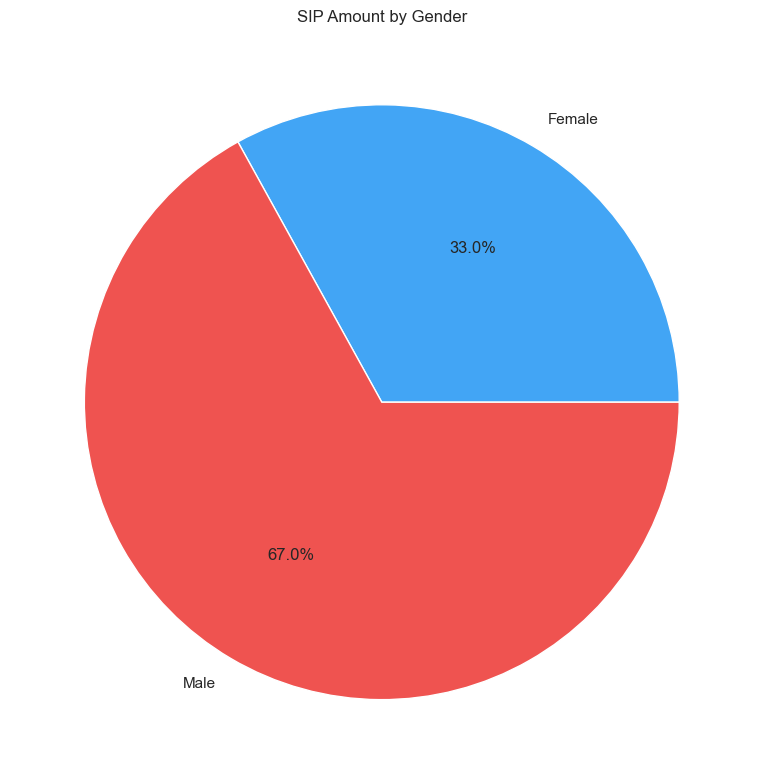

In [17]:
# Chart 15: Gender-wise SIP
df15 = df_tx[df_tx['transaction_type'].str.upper() == 'SIP'].copy()
gen_amt = df15.groupby('gender')['amount_inr'].sum()

plt.figure(figsize=(8, 8))
plt.pie(gen_amt, labels=gen_amt.index, autopct='%1.1f%%', colors=['#42A5F5','#EF5350'])
plt.title("SIP Amount by Gender")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart_15_gender_sip.png")
plt.show()

## Key EDA Findings
1. **Unprecedented SIP Growth**: SIP inflows reached an all-time high of Rs. 31,002 crore by December 2025, demonstrating massive retail investor confidence.
2. **Folio Expansion**: Total industry folios almost doubled from 13.26 crore in early 2022 to 26.12 crore by late 2025.
3. **SBI Dominance**: SBI Mutual Fund maintains a dominant lead in AUM, exceeding Rs. 12.5 Lakh Crore by 2025.
4. **Demographic Shift**: A significant portion of SIP transactions is driven by younger age brackets, particularly the 26-35 group.
5. **Geographic Spread**: Madhya Pradesh, Punjab, and Telangana lead total SIP contributions, indicating that SIP adoption extends well beyond the traditionally dominant metro cities.
6. **Tier-wise Distribution**: T30 cities still dominate SIP inflows, though B30 cities are capturing an increasing, meaningful slice of the pie.
7. **Consistent Equity Preference**: Equity folios continue to be the primary driver of total folio growth, vastly outpacing Debt and Hybrid.
8. **Sector Bias in Equity**: Consumer Goods, Diversified, and IT are the most heavily weighted sectors on average across equity fund portfolios, with Banking ranking 6th despite its high absolute weight due to concentrated positions in select funds.
9. **Strong NAV Recovery**: All tracked mutual funds exhibited a pronounced recovery following the 2024 correction, continuing the broader bull run.
10. **High Intra-Category Correlation**: Selected funds (e.g., Large Cap peers) show high positive correlations in daily NAV returns, indicating strong beta-driven market movements.